# Graph Generator

This notebook reproduces **Figures 3, 5, and 6** from the paper using the raw
per-second experiment data written by `evaluation.py`.

> **Don't have experiment results?** Use the pre-collected results from 
> my reproduce experiment run (3-node cluster, Social-Network benchmark):  
> [Download from Google Drive](https://drive.google.com/file/d/1Nos3wJxOJ4OfeiU0lmxox4MN-8gz0FMM/view?usp=sharing)  
> Extract and place according to the directory structure below.

## Expected Directory Structure
Place your experiment results (or the provided ones) at:
   `./experiment-results/autothrottle_results/`
```

experiment-results/
└── autothrottle_results/
    ├── data/
    │   └── social-network/
    │       ├── autothrottle-warmup/
    │       │   ├── a1/ … a6/          # exploration phase
    │       │   └── b1/ … b6/          # learning phase (ε = 0.5)
    │       ├── diurnal/
    │       │   ├── autothrottle/
    │       │   │   ├── stats.json.xz  <- per-second CPU, RPS, Tower actions
    │       │   │   └── request.log.xz <- per-request latency log
    │       │   ├── k8s-cpu/0.5/
    │       │   └── k8s-cpu-fast/0.5/
    │       ├── 500/                   # constant workload
    │       ├── noisy/
    │       └── bursty/
    ├── evaluation-3nodes.py
    ├── log.json                       <- aggregated per-run summary
    └── result.csv                     <- SLO pass/fail per run
```

## Figures Reproduced

| Figure | What it shows | Data source |
|:---:|---|---|
| **Fig 3** | RPS workload traces over 60 min | `stats.json.xz` -> `_global` RPS |
| **Fig 5** | Per-service CPU allocation vs usage (top 15) | `stats.json.xz` -> `scaler.limit`, `cpu_usage` |
| **Fig 6** | 60-min time series: latency, allocation, throttle targets | `stats.json.xz` + `request.log.xz` |


**Note:** `utils.py` from the autothrottle repo must be importable from this notebook's working directory.

In [38]:
import json, lzma, pathlib
import numpy as np
import json
import pathlib
import matplotlib
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

DATA_DIR = pathlib.Path('./experiment-results/autothrottle_results/data')

# utils.py must be importable
from utils import (
    load_cpu_limit, load_cpu_usage, load_request_latency, TimeSeries
)

plt.rcParams.update({
    'font.family':       'serif',
    'font.size':         11,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.grid':         True,
    'grid.alpha':        0.3,
    'grid.linestyle':    '--',
})

TOWER_TARGETS = [0.0, 0.02, 0.04, 0.06, 0.1, 0.15, 0.2, 0.25, 0.3]  # see the paper
WARMUP_S      = 3 * 60   # 3-minute warmup excluded from plots
SLO_S         = 0.2      # Social-Network SLO = 200 ms (stored in seconds)

# Social-Network experiment paths
PATHS = {
    'diurnal':   {
        'autothrottle':  DATA_DIR / 'social-network/diurnal/autothrottle',
        'k8s-cpu':       DATA_DIR / 'social-network/diurnal/k8s-cpu/0.5',
        'k8s-cpu-fast':  DATA_DIR / 'social-network/diurnal/k8s-cpu-fast/0.5',
    },
    'constant':  {
        'autothrottle':  DATA_DIR / 'social-network/500/autothrottle',
        'k8s-cpu':       DATA_DIR / 'social-network/500/k8s-cpu/0.5',
        'k8s-cpu-fast':  DATA_DIR / 'social-network/500/k8s-cpu-fast/0.6',
    },
    'noisy':     {
        'autothrottle':  DATA_DIR / 'social-network/noisy/autothrottle',
        'k8s-cpu':       DATA_DIR / 'social-network/noisy/k8s-cpu/0.5',
        'k8s-cpu-fast':  DATA_DIR / 'social-network/noisy/k8s-cpu-fast/0.4',
    },
    'bursty':    {
        'autothrottle':  DATA_DIR / 'social-network/bursty/autothrottle',
        'k8s-cpu':       DATA_DIR / 'social-network/bursty/k8s-cpu/0.5',
        'k8s-cpu-fast':  DATA_DIR / 'social-network/bursty/k8s-cpu-fast/0.4',
    },
}

print('Paths configured. Checking data availability...')
for wl, scalers in PATHS.items():
    for scaler, p in scalers.items():
        exists = (p / 'stats.json.xz').exists()
        status = 'v' if exists else 'x MISSING'
        print(f'  [{status}] {wl}/{scaler}')

Paths configured. Checking data availability...
  [v] diurnal/autothrottle
  [v] diurnal/k8s-cpu
  [v] diurnal/k8s-cpu-fast
  [v] constant/autothrottle
  [v] constant/k8s-cpu
  [v] constant/k8s-cpu-fast
  [v] noisy/autothrottle
  [v] noisy/k8s-cpu
  [v] noisy/k8s-cpu-fast
  [v] bursty/autothrottle
  [v] bursty/k8s-cpu
  [v] bursty/k8s-cpu-fast


## Figure 5 - Per-Service CPU Allocation vs Usage

The paper uses the **diurnal / autothrottle** run to show the top 15 services  
by CPU usage, comparing average CPU allocation (limit) against average CPU usage.  
Autothrottle tailors each service's allocation closely to its actual demand.

In [39]:
def service_alloc_usage(path, warmup_s=WARMUP_S):
    """Return {service: (avg_allocation_cores, avg_usage_cores)} trimmed to eval window."""
    limits = load_cpu_limit(path)    # {service: TimeSeries of cpu limit in cores}
    usages = load_cpu_usage(path)    # {service: TimeSeries of cpu usage rate in cores}
    result = {}
    for svc in limits:
        lim = limits[svc].slice(warmup_s, float('inf'))
        if not lim:
            continue
        avg_lim = lim.average()
        if svc in usages:
            usg = usages[svc].slice(warmup_s, float('inf'))
            avg_usg = usg.average() if usg else 0.0
        else:
            avg_usg = 0.0
        result[svc] = (avg_lim, avg_usg)
    return result

path_diurnal_at = PATHS['diurnal']['autothrottle']

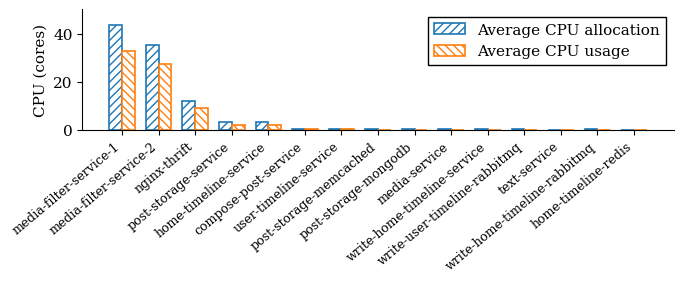

In [ ]:
svc_data = service_alloc_usage(path_diurnal_at)

# Sort by usage (descending) and take top 15
top15 = sorted(svc_data.items(), key=lambda kv: kv[1][1], reverse=True)[:15]

names  = [k for k, _ in top15]
allocs = [v[0] for _, v in top15]
usages = [v[1] for _, v in top15]

x = np.arange(len(names))
width = 0.35

fig, ax = plt.subplots(figsize=(7, 3))

ax.bar(
    x - width/2,
    allocs,
    width,
    label='Average CPU allocation',
    facecolor='white',
    edgecolor='tab:blue',
    hatch='////',
    linewidth=1.2
)

ax.bar(
    x + width/2,
    usages,
    width,
    label='Average CPU usage',
    facecolor='white',
    edgecolor='tab:orange',
    hatch='\\\\\\\\',
    linewidth=1.2
)

ax.set_ylabel('CPU (cores)')
ax.set_xticks(x)
ax.set_xticklabels(names, rotation=40, ha='right', fontsize=9)

ax.set_ylim(0, max(allocs) * 1.15)

ax.legend(
    loc='upper right',
    frameon=True,
    fancybox=False,
    framealpha=1,
    edgecolor='black'
)

ax.grid(False)

fig.tight_layout()

# Uncomment if you want to save the results
# fig.savefig('fig5.png', bbox_inches='tight', dpi=200)
plt.show()

## Figure 6 - 60-Minute Time Series (Social-Network, Diurnal, Autothrottle)

The paper shows four sub-panels for the diurnal/autothrottle run:
- **(a)** Application P99 latency per minute
- **(b)** Total CPU allocation and usage over time  
- **(c)** Tower throttle target for the high-CPU group (Group 1 = `media-filter-service`)
- **(d)** Tower throttle target for the low-CPU group (Group 2 = all other services)

The throttle target is decoded from the `_tower.action` field:  
`action` is an index 0–80 into a 9×9 grid.  
`target1 = TOWER_TARGETS[action // 9]`, `target2 = TOWER_TARGETS[action % 9]`.

In [41]:
def load_tower_stats(path):
    """Return list of (t_sec, {rps, p99_latency, allocation, action, ...}) for _tower."""
    path = pathlib.Path(path)
    with lzma.open(path / 'stats.json.xz', 'rt') as f:
        stats = json.load(f)
    return stats.get('_tower', [])


def load_per_minute_latency(path, warmup_s=WARMUP_S):
    """P99 latency per minute from the raw request log."""
    rl = load_request_latency(path).slice(warmup_s, float('inf'))
    p99_min = rl.downsample_percentage(60, 99)
    t0 = p99_min[0][0]
    ts  = [(t - t0) / 60 for t, _ in p99_min]
    p99 = [v * 1000 for _, v in p99_min]   # convert s to ms
    return ts, p99


def load_per_minute_alloc_and_usage(path, warmup_s=WARMUP_S):
    """Total CPU allocation and total CPU usage, each downsampled to 1-min averages."""
    # total allocation = sum across all services
    limits = load_cpu_limit(path)
    total_lim = TimeSeries.zip_with(
        lambda *args: sum(args), *limits.values()
    ).slice(warmup_s, float('inf')).downsample_time_weighted_average(60)

    usages = load_cpu_usage(path)
    total_usg = TimeSeries.zip_with(
        lambda *args: sum(args), *usages.values()
    ).slice(warmup_s, float('inf')).downsample_average(60)

    t0 = total_lim[0][0]
    t_min  = [(t - t0) / 60 for t, _ in total_lim]
    allocs = [v for _, v in total_lim]
    t0u    = total_usg[0][0]
    t_min_u = [(t - t0u) / 60 for t, _ in total_usg]
    usgs   = [v for _, v in total_usg]
    return t_min, allocs, t_min_u, usgs


def load_throttle_targets(path, warmup_s=WARMUP_S):
    """Return (t_min, target1_list, target2_list) decoded from Tower actions."""
    tower = load_tower_stats(path)
    t_min, t1_list, t2_list = [], [], []
    for t_sec, d in tower:
        if t_sec < warmup_s:
            continue
        if 'action' not in d:
            continue
        action  = d['action']
        target1 = TOWER_TARGETS[action // len(TOWER_TARGETS)]
        target2 = TOWER_TARGETS[action % len(TOWER_TARGETS)]
        t_min.append((t_sec - warmup_s) / 60)
        t1_list.append(target1)
        t2_list.append(target2)
    return t_min, t1_list, t2_list

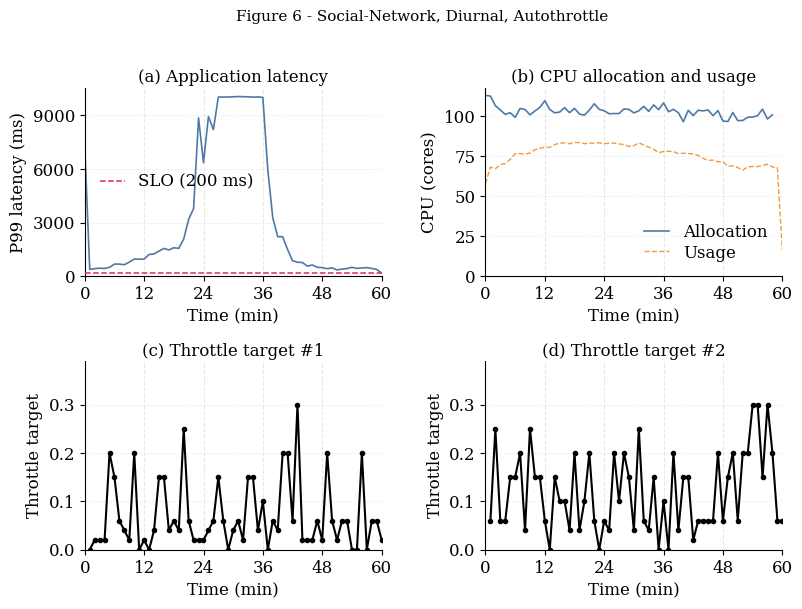

In [ ]:
path_diurnal_at = PATHS['diurnal']['autothrottle']

t_lat, p99_vals           = load_per_minute_latency(path_diurnal_at)
t_a, alloc_v, t_u, usg_v = load_per_minute_alloc_and_usage(path_diurnal_at)
t_thr, thr1, thr2         = load_throttle_targets(path_diurnal_at)

XTICKS = [0, 12, 24, 36, 48, 60]

fig, axes = plt.subplots(2, 2, figsize=(9, 6),
                          gridspec_kw={'hspace': 0.45, 'wspace': 0.35})

# (a) Application latency
ax = axes[0, 0]
ax.plot(t_lat, p99_vals, color='#4e79a7', linewidth=1.2)
ax.axhline(SLO_S * 1000, color='#e12759', linestyle='--',
           linewidth=1.1, label=f'SLO ({int(SLO_S*1000)} ms)', zorder=4)
ax.set_ylabel('P99 latency (ms)', fontsize=12)
ax.set_ylim(bottom=0)
ax.yaxis.set_major_locator(matplotlib.ticker.MaxNLocator(nbins=4, integer=True))
ax.set_title('(a) Application latency', fontsize=12, pad=4)
ax.legend(frameon=False, fontsize=12, handlelength=1.5)
ax.set_xlabel('Time (min)', fontsize=12)

# (b) CPU allocation and usage
ax = axes[0, 1]
ax.plot(t_a, alloc_v, color='#4e79a7', linewidth=1.2, label='Allocation')
ax.plot(t_u, usg_v,   color='#f28e2b', linewidth=1.0, linestyle='--',
        label='Usage', alpha=0.9)
ax.set_ylabel('CPU (cores)', fontsize=12)
ax.set_ylim(bottom=0)
ax.set_title('(b) CPU allocation and usage', fontsize=12, pad=4)
ax.legend(frameon=False, fontsize=12, loc='lower right',
          handlelength=1.5, labelspacing=0.2)
ax.set_xlabel('Time (min)', fontsize=12)

# (c) Throttle target #1 (high-CPU group)
ax = axes[1, 0]
ax.plot(t_thr, thr1, color="black", marker='o', markersize=3)
ax.set_ylabel('Throttle target', fontsize=12)
y1_max = max(thr1) * 1.3
ax.set_ylim(0.0, y1_max)
ax.yaxis.set_major_locator(matplotlib.ticker.MaxNLocator(nbins=4))
ax.set_title('(c) Throttle target #1', fontsize=12, pad=4)
ax.set_xlabel('Time (min)', fontsize=12)

# (d) Throttle target #2 (low-CPU group)
ax = axes[1, 1]
ax.plot(t_thr, thr2, color="black", marker='o', markersize=3)
ax.set_ylabel('Throttle target', fontsize=12)
y2_max = max(thr2) * 1.3
ax.set_ylim(0.0, y2_max)
ax.yaxis.set_major_locator(matplotlib.ticker.MaxNLocator(nbins=4))
ax.set_title('(d) Throttle target #2', fontsize=12, pad=4)
ax.set_xlabel('Time (min)', fontsize=12)

# Shared formatting
for ax in axes.flat:
    ax.set_xlim(0, 60)
    ax.set_xticks(XTICKS)
    ax.tick_params(labelsize=12)
    ax.grid(axis='y', alpha=0.25, linestyle='--', linewidth=0.5)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.suptitle('Figure 6 - Social-Network, Diurnal, Autothrottle', fontsize=11, y=1.01)

# Uncomment if you want to save the results
# fig.savefig('fig6.png', bbox_inches='tight', dpi=200)
plt.show()

## Figure 6 (extended) - Compare Autothrottle vs K8s-CPU vs K8s-CPU-Fast

The paper only shows the Autothrottle run in Figure 6. As an extension,  
we overlay all three scalers on the allocation and latency panels for the **diurnal workload**.  
This is a natural addition for your write-up.

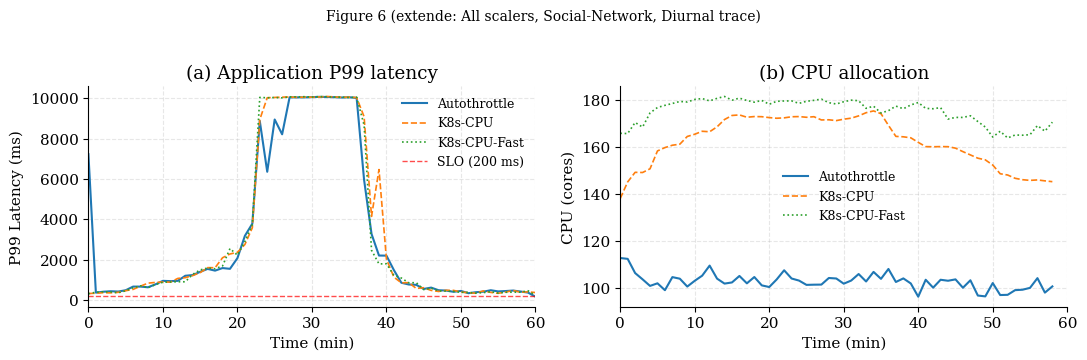

Saved fig6_extended_comparison.pdf / .png


In [43]:
SCALER_STYLE = {
    'autothrottle': dict(color='#1f77b4',   label='Autothrottle', linewidth=1.5),
    'k8s-cpu':      dict(color='#ff7f0e',  label='K8s-CPU',      linewidth=1.2, linestyle='--'),
    'k8s-cpu-fast': dict(color='#2ca02c', label='K8s-CPU-Fast',  linewidth=1.2, linestyle=':'),
}

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
fig.suptitle(
    'Figure 6 (extende: All scalers, Social-Network, Diurnal trace)',
    fontsize=10, y=1.02
)

for scaler, style in SCALER_STYLE.items():
    path = PATHS['diurnal'][scaler]
    try:
        # Latency
        t_lat, p99_v = load_per_minute_latency(path)
        axes[0].plot(t_lat, p99_v, **style)

        # Allocation
        t_a, alloc_v, _, _ = load_per_minute_alloc_and_usage(path)
        axes[1].plot(t_a, alloc_v, **style)

    except Exception as e:
        print(f'  {scaler}: {e}')

axes[0].axhline(SLO_S * 1000, color='red', linestyle='--', linewidth=1, alpha=0.7,
                label=f'SLO ({SLO_S*1000:.0f} ms)')
axes[0].set_xlabel('Time (min)'); axes[0].set_ylabel('P99 Latency (ms)')
axes[0].set_title('(a) Application P99 latency')
axes[0].legend(frameon=False, fontsize=9)

axes[1].set_xlabel('Time (min)'); axes[1].set_ylabel('CPU (cores)')
axes[1].set_title('(b) CPU allocation')
axes[1].legend(frameon=False, fontsize=9)

for ax in axes:
    ax.set_xlim(0, 60)

fig.tight_layout()

# Uncomment if you want to save the results
# fig.savefig('fig6_extended.png', bbox_inches='tight', dpi=200)
plt.show()

## Table 1 (b) - Autothrottle's CPU Saving Comparison for Social-Network Application 

In [44]:
def make_table1():
    log_path = pathlib.Path("log.json")

    records = []
    with open(log_path) as f:
        for line in f:
            if line.strip():
                records.append(json.loads(line))

    df = pd.DataFrame(records)
    df = df[df["warmup"].isna()].copy()

    TRACE_MAP  = {"diurnal":"Diurnal",500:"Constant","noisy":"Noisy","bursty":"Bursty"}
    SCALER_MAP = {"autothrottle":"Autothrottle","k8s-cpu":"K8s-CPU","k8s-cpu-fast":"K8s-CPU-Fast"}

    df["Workload"] = df["trace"].map(TRACE_MAP)
    df["Scaler"] = df["scaler"].map(SCALER_MAP)

    pivot = df.pivot(index="Workload", columns="Scaler", values="allocation")

    workloads = ["Diurnal","Constant","Noisy","Bursty"]
    pivot = pivot.loc[workloads]

    # compute savings
    k8s_save = (pivot["K8s-CPU"] - pivot["Autothrottle"]) / pivot["K8s-CPU"] * 100
    kf_save  = (pivot["K8s-CPU-Fast"] - pivot["Autothrottle"]) / pivot["K8s-CPU-Fast"] * 100

    table = pd.DataFrame({
        "Autothrottle": pivot["Autothrottle"].round(1),
        "K8s-CPU": pivot["K8s-CPU"].round(1).astype(str)
                   + " (↓" + k8s_save.round(1).astype(str) + "%)",
        "K8s-CPU-Fast": pivot["K8s-CPU-Fast"].round(1).astype(str)
                   + " (↓" + kf_save.round(1).astype(str) + "%)"
    })

    styler = (
        table.style
        .format({"Autothrottle": "{:.1f}"})
        .set_properties(**{
            "text-align": "center",
            "font-family": "serif",
            "font-size": "12pt"
        })
        .set_table_styles([
            {"selector":"th","props":[("font-weight","bold")]},
            {"selector":"table","props":[("border-top","2px solid black"),
                                         ("border-bottom","2px solid black")]},
            {"selector":"thead","props":[("border-bottom","1px solid black")]}
        ])
    )

    display(styler)

In [45]:
make_table1()

,Autothrottle,K8s-CPU,K8s-CPU-Fast
Workload,,,
Diurnal,102.6,161.7 (↓36.6%),174.9 (↓41.3%)
Constant,103.5,170.2 (↓39.2%),150.1 (↓31.1%)
Noisy,99.9,138.5 (↓27.9%),198.4 (↓49.7%)
Bursty,96.4,132.8 (↓27.4%),183.0 (↓47.3%)
